In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import interp1d

# --- Third-party imports ---
from lifelines.utils import concordance_index

from sksurv.metrics import cumulative_dynamic_auc
from sksurv.util import Surv

from sklearn.metrics import brier_score_loss


In [5]:
uniq_gene = pd.read_csv('uniq_gene_20240101.csv')

In [37]:
beta_relapse = pd.read_csv('data/relapsed_beta_values.csv', index_col = 0)

In [38]:
beta_relapse

,7990895093_R05C02,9741950085_R06C02,8622007028_R02C02,202073220074_R07C01,9285451180_R03C01,9285451180_R04C01,9285451180_R01C01,9285451180_R02C01,9285451180_R01C02,9285451180_R02C02,...,9341679006_R01C02,9341679006_R02C02,9341679014_R03C01,9341679014_R04C01,9305216139_R05C02,9305216139_R06C02,9305216139_R03C02,9305216139_R04C02,9285451180_R05C01,9285451180_R06C01
cg21870274,0.722853,0.683029,0.687491,0.831225,0.868453,0.869024,0.438340,0.441922,0.680456,0.758977,...,0.589259,0.563717,0.829077,0.754902,0.771083,0.545871,0.844617,0.541592,0.747749,0.809680
cg08258224,0.584376,0.688118,0.792970,0.801583,0.811696,0.774990,0.794589,0.773084,0.597067,0.775031,...,0.763893,0.742134,0.630607,0.833407,0.709515,0.623255,0.782254,0.735544,0.716926,0.705809
cg16619049,0.160938,0.074497,0.187111,0.041655,0.110833,0.094178,0.126043,0.164002,0.096635,0.094264,...,0.171280,0.192997,0.221124,0.161020,0.186037,0.165734,0.212355,0.245552,0.080190,0.061044
cg13938959,0.306192,0.204812,0.883219,0.865765,0.725359,0.741597,0.873536,0.862568,0.731437,0.811235,...,0.802559,0.910204,0.838677,0.747435,0.648702,0.631899,0.664060,0.848801,0.775379,0.873566
cg12445832,0.166687,0.084534,0.776106,0.770561,0.528350,0.429469,0.731936,0.727963,0.173822,0.218784,...,0.577099,0.664494,0.563986,0.487846,0.292892,0.173921,0.381975,0.249189,0.429620,0.705202
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
cg05615487,0.617234,0.650152,0.616120,0.609518,0.562309,0.501573,0.457844,0.394727,0.769118,0.644467,...,0.733128,0.778223,0.836170,0.894926,0.834507,0.778487,0.854553,0.889717,0.599833,0.622428
cg22122449,0.590933,0.698869,0.647373,0.570098,0.728105,0.636666,0.424704,0.218674,0.554191,0.856191,...,0.793862,0.687756,0.779518,0.675642,0.634834,0.724157,0.755167,0.826763,0.697500,0.618352
cg08423507,0.238084,0.020313,0.412333,0.181030,0.226408,0.211046,0.079579,0.183628,0.398983,0.754544,...,0.148164,0.181070,0.706747,0.420881,0.349895,0.222761,0.226081,0.304134,0.559662,0.710976
cg09007244,0.167071,0.054213,0.047650,0.048127,0.098744,0.053970,0.039934,0.039033,0.040263,0.041852,...,0.037215,0.039617,0.056879,0.052177,0.035125,0.075707,0.056908,0.048418,0.036021,0.036087


In [41]:
relapse_meta = pd.read_csv('/hovestadtlab/sabina/methylation-survival/full_metadata/Relapse_metadata_ks09182019.txt', sep = '\t', index_col = 0)

In [43]:
np.zeros(len(relapse_meta))

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0.

In [45]:
relapse_meta

pd.DataFrame({"Patient_ID": relapse_meta.index, "m": np.zeros(len(relapse_meta)), "age": relapse_meta["Age.1"]}).set_index("Patient_ID")

,m,age
Patient_ID,,
7990895093_R05C02,0.0,7.000000
9741950085_R06C02,0.0,9.000000
8622007028_R02C02,0.0,16.000000
202073220074_R07C01,0.0,32.000000
9285451180_R03C01,0.0,5.000000
...,...,...
9305216139_R06C02,0.0,7.566667
9305216139_R03C02,0.0,10.100000
9305216139_R04C02,0.0,11.700000


In [9]:
cnv_cavalli = pd.read_csv('data/cnv_cavalli.csv', header = None)

In [ ]:
cnv_cavalli = pd.read_csv('data/cnv_cavalli.csv', header = None)
surv_cav = pd.read_csv('data/surv_cavalli.csv')
cnv_cavalli.columns = surv_cav['idat'].values
cnv_cavalli.index = uniq_gene.name
cnv_cavalli.index.name = 'gene'
cnv_cavalli.to_csv('data/cnv_cavalli.csv')

In [24]:
cnv_cavalli = pd.read_csv('data/cnv_cavalli.csv',index_col = 0)
cnv_cavalli

,7796806110_R01C01,7796806110_R02C01,7796806110_R04C02,7796806110_R06C01,7810920068_R01C01,7810920068_R01C02,7810920068_R02C01,7810920068_R02C02,7810920068_R03C01,7810920068_R03C02,...,9344737044_R06C01,9344737073_R01C01,9344737073_R03C01,9344737073_R03C02,9344737073_R04C01,9344737073_R05C02,9344737082_R01C02,9344737104_R02C01,9344737104_R05C02,9344737104_R06C01
gene,,,,,,,,,,,,,,,,,,,,,
SAMD11,0.036746,-0.042059,-0.132367,-0.035629,-0.013463,0.100821,0.023560,0.084718,0.021973,-0.001075,...,0.036075,0.013033,0.070144,-0.023379,-0.006933,-0.064484,-0.027112,-0.117748,0.030854,0.017040
NOC2L,0.074550,0.007140,-0.013992,0.064831,-0.096137,0.087142,-0.041087,-0.045735,-0.056567,-0.023292,...,0.117106,0.107650,0.133653,0.131156,-0.008761,0.055979,0.058386,-0.016292,0.189042,0.108550
KLHL17,0.028112,-0.063691,-0.096172,0.023648,-0.049936,0.166430,0.054257,0.063978,-0.057538,0.020698,...,-0.004785,-0.009167,0.017448,0.058759,-0.029008,-0.084954,0.033090,-0.113725,0.049044,0.007953
PLEKHN1,0.088221,-0.007206,-0.096203,-0.010855,-0.022600,0.074987,0.087967,0.109646,-0.125422,0.023932,...,-0.060831,-0.064143,0.138046,-0.000316,0.016855,0.046908,0.082046,-0.033214,0.210133,0.175819
PERM1,-0.177229,-0.037100,-0.108144,-0.111615,-0.130670,0.044987,-0.175156,-0.008103,-0.288944,-0.290247,...,-0.141497,-0.070957,-0.017729,-0.148000,-0.182465,-0.087320,0.030494,-0.168854,0.054541,-0.107504
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CHKB,0.051076,-0.032236,-0.048905,0.099925,-0.032619,0.125447,0.040703,0.096455,0.145098,-0.028940,...,0.156867,-0.032703,0.066985,0.090095,-0.023092,-0.093009,0.129038,0.099433,0.111235,0.031232
MAPK8IP2,-0.049065,-0.025232,-0.079597,0.011649,-0.067075,0.127858,0.072513,0.127746,0.087538,-0.063929,...,0.259174,0.027414,0.060325,0.171818,0.115775,-0.017182,0.109879,0.160141,0.147240,0.165705
ARSA,-0.056735,-0.037812,-0.134772,0.005923,-0.094092,0.137421,0.019865,0.033256,0.027977,-0.171713,...,0.192502,-0.170397,0.027181,-0.048768,-0.012499,-0.236947,0.063536,0.027369,-0.007146,0.085942


In [25]:
cnv_jones = pd.read_csv('data/cnv_jones.csv', header = None)
surv_jones = pd.read_csv('data/surv_jones.csv')
cnv_jones.columns = surv_jones['idat'].values
cnv_jones.index = uniq_gene.name
cnv_jones.index.name = 'gene'
cnv_jones.to_csv('data/cnv_jones.csv')

In [26]:
cnv_northcott = pd.read_csv('data/cnv_northcott.csv', header = None)
surv_northcott = pd.read_csv('data/surv_northcott.csv')
cnv_northcott.columns = surv_northcott['idat'].values
cnv_northcott.index = uniq_gene.name
cnv_northcott.index.name = 'gene'
cnv_northcott.to_csv('data/cnv_northcott.csv')

In [27]:
cnv_sturm = pd.read_csv('data/cnv_sturm.csv', header = None)
surv_sturm = pd.read_csv('data/surv_sturm.csv')
cnv_sturm.columns = surv_sturm['idat'].values
cnv_sturm.index = uniq_gene.name
cnv_sturm.index.name = 'gene'
cnv_sturm.to_csv('data/cnv_sturm.csv')

In [28]:
cnv_g34_test = pd.read_csv('data/CNV_g34_test.csv', header = None)
surv_g34_test = pd.read_csv('data/group34_rCM_samples.csv')
cnv_g34_test.columns = surv_g34_test['idat'].values
cnv_g34_test.index = uniq_gene.name
cnv_g34_test.index.name = 'gene'
cnv_g34_test.to_csv('data/CNV_g34_test.csv')

In [31]:
relapsed_cnv = pd.read_csv('data/relapsed_CNV_gene_values.csv', index_col = 0)

In [ ]:
beta_cavalli = pd.read_csv('data/beta_cavalli.csv', index_col = 0)


,7796806110_R01C01,7796806110_R02C01,7796806110_R04C02,7796806110_R06C01,7810920068_R01C01,7810920068_R01C02,7810920068_R02C01,7810920068_R02C02,7810920068_R03C01,7810920068_R03C02,...,9344737044_R06C01,9344737073_R01C01,9344737073_R03C01,9344737073_R03C02,9344737073_R04C01,9344737073_R05C02,9344737082_R01C02,9344737104_R02C01,9344737104_R05C02,9344737104_R06C01
cg21870274,0.357720,0.646857,0.720404,0.916192,0.603767,0.637606,0.759358,0.869782,0.801935,0.652322,...,0.536310,0.591601,0.716915,0.478878,0.681219,0.664384,0.702015,0.815227,0.895849,0.819059
cg08258224,0.467129,0.840234,0.807882,0.814786,0.886030,0.875462,0.899187,0.866630,0.528449,0.791275,...,0.541148,0.811135,0.843883,0.610711,0.437202,0.774520,0.667830,0.674494,0.842357,0.830005
cg16619049,0.115626,0.088999,0.076715,0.127258,0.090702,0.126099,0.076010,0.099267,0.097135,0.064628,...,0.089099,0.076603,0.181310,0.123898,0.116785,0.114851,0.056771,0.081724,0.185141,0.079078
cg13938959,0.467549,0.857844,0.692533,0.565313,0.938371,0.905756,0.772168,0.925614,0.506036,0.639403,...,0.524841,0.769252,0.833753,0.492933,0.718458,0.802716,0.852768,0.846323,0.924317,0.735574
cg12445832,0.137186,0.448626,0.441199,0.120930,0.867691,0.797698,0.662613,0.874158,0.093127,0.317814,...,0.130799,0.199232,0.419498,0.292551,0.103023,0.571883,0.328864,0.360864,0.840543,0.525298
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
cg05615487,0.452833,0.587973,0.876637,0.739168,0.906500,0.902781,0.593111,0.474487,0.755855,0.627160,...,0.672074,0.852711,0.846662,0.571958,0.829862,0.877506,0.481380,0.750113,0.898328,0.419729
cg22122449,0.283465,0.729854,0.392769,0.591939,0.884937,0.505579,0.479007,0.431095,0.689929,0.440672,...,0.204616,0.415394,0.806906,0.443603,0.294694,0.688639,0.743394,0.580961,0.807196,0.437202
cg08423507,0.164006,0.650144,0.411097,0.371856,0.253150,0.271160,0.232474,0.174432,0.832952,0.797855,...,0.082634,0.225486,0.218766,0.290789,0.386454,0.559178,0.639584,0.642796,0.110519,0.332451
cg09007244,0.032039,0.032886,0.027708,0.027527,0.026917,0.032067,0.029892,0.032941,0.042264,0.052140,...,0.034474,0.023969,0.027418,0.040322,0.034905,0.025210,0.023720,0.026454,0.039392,0.022539


In [34]:
beta_cavalli.index

Index(['cg21870274', 'cg08258224', 'cg16619049', 'cg13938959', 'cg12445832',
       'cg23999112', 'cg11527153', 'cg04195702', 'cg08128007', 'cg23733394',
       ...
       'cg09635994', 'cg19004771', 'cg20569369', 'cg26034629', 'cg25232725',
       'cg05615487', 'cg22122449', 'cg08423507', 'cg09007244', 'cg19565306'],
      dtype='object', length=357692)

In [23]:
cnv_cavalli.to_csv('data/cnv_cavalli.csv')

In [15]:
prbs = pd.read_csv('probe2singlegene_357692probes.vh231024.txt', sep = '\t')

In [17]:
beta_cav = pd.read_csv('data/beta_cavalli.csv', header = None)
surv_cav = pd.read_csv('data/surv_cavalli.csv')

In [19]:
beta_cav.columns = surv_cav['idat'].values
beta_cav.index = prbs.index

In [21]:
beta_cav.to_csv('data/beta_cavalli.csv') #, header = None, index = False)

In [22]:
beta_jones = pd.read_csv('data/beta_jones.csv', header = None)
surv_jones = pd.read_csv('data/surv_jones.csv')
beta_jones.columns = surv_jones['idat'].values
beta_jones.index = prbs.index
beta_jones.to_csv('data/beta_jones.csv')

In [24]:
beta_jones = pd.read_csv('data/beta_jones.csv', index_col = 0)
beta_jones

,6929718001_R04C02,6929793052_R02C02,6929718001_R05C02,6929793052_R03C02,6929793052_R04C02,6969568004_R03C01,6929718001_R06C02,6969568004_R04C01,9855358048_R04C01,6929793052_R05C02,...,9855358053_R03C02,9007217016_R03C02,9007217016_R01C01,9855358053_R05C02,9007217016_R06C01,9007217108_R01C01,9007217108_R03C02,9855358058_R06C02,9855358064_R02C01,9855358064_R03C01
cg21870274,0.828558,0.797897,0.540127,0.717721,0.888237,0.693602,0.714978,0.700579,0.858246,0.763568,...,0.507816,0.927314,0.657935,0.766334,0.924733,0.756275,0.706224,0.890478,0.748062,0.759468
cg08258224,0.694328,0.889895,0.824369,0.697077,0.887639,0.505729,0.490959,0.688932,0.795890,0.792835,...,0.729307,0.589554,0.738631,0.797988,0.895393,0.506489,0.786208,0.877926,0.841497,0.726118
cg16619049,0.072470,0.103672,0.100461,0.095977,0.088752,0.077900,0.048522,0.099229,0.085210,0.242048,...,0.094399,0.091563,0.078951,0.084007,0.071556,0.077594,0.064964,0.035945,0.131942,0.081188
cg13938959,0.420788,0.905422,0.931931,0.753302,0.910836,0.577508,0.658058,0.625285,0.750113,0.911779,...,0.806429,0.828616,0.896175,0.745795,0.545735,0.647585,0.693909,0.868896,0.856130,0.506376
cg12445832,0.223830,0.598983,0.842065,0.504316,0.540841,0.062123,0.104788,0.164624,0.373316,0.832856,...,0.462997,0.471637,0.471856,0.355999,0.197549,0.293858,0.228836,0.125062,0.669126,0.156897
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
cg05615487,0.865918,0.842286,0.857975,0.784140,0.566866,0.854471,0.508163,0.304110,0.654335,0.805792,...,0.613418,0.858147,0.528494,0.706252,0.903227,0.404496,0.785921,0.865392,0.669139,0.855577
cg22122449,0.452144,0.721864,0.608598,0.755282,0.852995,0.525783,0.310720,0.270792,0.379273,0.678310,...,0.372052,0.753960,0.477070,0.625913,0.864155,0.532765,0.383993,0.524466,0.694510,0.550892
cg08423507,0.170059,0.421595,0.272261,0.816392,0.664498,0.432667,0.225058,0.090957,0.127288,0.411195,...,0.096395,0.383587,0.488672,0.490251,0.454768,0.335127,0.573517,0.668801,0.855407,0.630386
cg09007244,0.030424,0.031562,0.032138,0.037195,0.028903,0.029797,0.035189,0.027420,0.043168,0.035186,...,0.037768,0.034016,0.027026,0.054195,0.046992,0.028956,0.036720,0.023534,0.024009,0.041170


In [23]:
beta_sturm = pd.read_csv('data/beta_sturm.csv', header = None)
surv_sturm = pd.read_csv('data/surv_sturm.csv')
beta_sturm.columns = surv_sturm['idat'].values
beta_sturm.index = prbs.index
beta_sturm.to_csv('data/beta_sturm.csv')

In [25]:
beta_northcott = pd.read_csv('data/beta_northcott.csv', header = None)
surv_northcott = pd.read_csv('data/surv_northcott.csv')
beta_northcott.columns = surv_northcott['idat'].values
beta_northcott.index = prbs.index
beta_northcott.to_csv('data/beta_northcott.csv')

In [28]:
beta_sj_average = pd.read_csv('data/beta_sj_average.csv', header = None)
surv_sj_average = pd.read_csv('data/surv_sj_average.csv')
beta_sj_average.columns = surv_sj_average['Patient_ID'].values
beta_sj_average.index = prbs.index
beta_sj_average.to_csv('data/beta_sj_average.csv')

In [29]:
beta_sj_high = pd.read_csv('data/beta_sj_high.csv', header = None)
surv_sj_high = pd.read_csv('data/surv_sj_high.csv')
beta_sj_high.columns = surv_sj_high['Patient_ID'].values
beta_sj_high.index = prbs.index
beta_sj_high.to_csv('data/beta_sj_high.csv')

In [2]:
beta_val = pd.read_csv('data/beta_val_uniform_illumina_rCM_g34.csv', header = None)

In [5]:
g34_cm_surv = pd.read_csv('/hovestadtlab/sabina/methylation-survival/data/group34_rCM_samples.csv')

In [12]:
beta_val.columns = g34_cm_surv['idat'].values
beta_val.index = prbs.index
# g34_cm_surv

In [3]:
# beta_val.fillna(beta_val_og, inplace=True)
beta_val.isna().sum()

0      0
1      0
2      0
3      0
4      0
      ..
599    0
600    0
601    0
602    0
603    0
Length: 604, dtype: int64

In [14]:
beta_val.to_csv('data/beta_val_uniform_illumina_rCM_g34.csv') #, header = None, index = False)

In [12]:
rcm_pred = pd.read_csv("results/rCM_predictions.csv", index_col=0)
rcm_surv = pd.read_csv("data/group34_rCM_samples.csv")

rcm_surv

,cohort,tot_id,mantis_risk,event,pfs_status,time,pfs_time,idat,m,rcm_int
0,SJMB03,SJMB066997,0.721599,0,0,10.683094,10.683094,9934987047_R03C02,1,3
1,ACNS332,PARYKD,0.828103,0,0,10.268493,10.268493,201980430112_R04C01,0,2
2,ACNS331,PAPTTH,0.782002,0,0,4.167123,4.167123,202232290159_R07C01,0,2
3,ACNS332,PAWUUW,0.721505,0,0,3.704110,3.704110,202234370044_R06C01,1,3
4,ACNS332,PAXPHY,0.108784,1,1,0.561644,0.024658,202234370002_R01C01,1,3
...,...,...,...,...,...,...,...,...,...,...
599,ACNS331,PANXEA,0.852520,0,0,4.136986,4.136986,202787550003_R02C01,0,1
600,ACNS331,PATCAR,0.891183,0,0,9.090411,9.090411,202784980009_R03C01,0,2
601,ACNS331,PATSCV,0.863338,0,0,8.947945,8.947945,202790040020_R03C01,0,2
602,ACNS331,PASZEL,0.830300,0,0,4.010959,4.010959,202784980008_R05C01,0,2


In [13]:
sjmb03_pred = pd.read_csv('/hovestadtlab/sabina/methylation-survival/results/sjmb03_predictions.csv')
sjmb03_pred.set_index('Patient_ID', inplace=True) 
time_bins = [0.019167, 0.33333, 0.5847, 0.75, 0.94167, 1.1667, 1.5, 1.8333, 2.0833, 2.5833, 3.25, 3.9, 5.6667, 8.2875, 22.0]

surv_sj_high = pd.read_csv('/hovestadtlab/sabina/methylation-survival/data/surv_sj_high.csv')

In [18]:
test_samples

array([[1.        , 0.99353164, 0.97017252, ..., 0.66329151, 0.65944827,
        0.22876133],
       [0.99999994, 0.99996769, 0.9997046 , ..., 0.66393769, 0.58453244,
        0.0830555 ],
       [1.        , 0.99998558, 0.99991429, ..., 0.70917857, 0.67526394,
        0.11159755],
       ...,
       [1.        , 0.99999714, 0.99998081, ..., 0.76024699, 0.70679784,
        0.08830937],
       [1.        , 0.99999011, 0.99996209, ..., 0.74244297, 0.69392461,
        0.06492932],
       [0.99999994, 0.9999969 , 0.99998492, ..., 0.95371294, 0.93222427,
        0.26372007]], shape=(604, 16))

In [28]:
# test_samples = sjmb03_pred.values #[high_risk,]
# t_test_np = surv_sj_high['time'].values #[high_risk]
# e_test_np = surv_sj_high['event'].values #[high_risk]

# t_test_np = surv_sj_high['pfs_time_yrs'].values #[high_risk]
# e_test_np = surv_sj_high['pfs_event'].values #[high_risk]

test_samples = rcm_pred.values
t_test_np = rcm_surv['time'].values
e_test_np = rcm_surv['event'].values
n_test_samples = test_samples.shape[0]
pred_times = np.concatenate(([0.0], time_bins))
eval_times = np.arange(0.1, 10.01, 0.1)


interpolated_probs = np.zeros((n_test_samples, len(eval_times)))

for i in range(n_test_samples):
    y_interp = test_samples[i, :]
    interp_func = interp1d(
        pred_times,
        y_interp,
        kind='linear',
        bounds_error=False,
        fill_value=(y_interp[0], y_interp[-1])
    )
    interpolated_probs[i, :] = interp_func(eval_times)

    # force survival at time 0 to be 1
    interpolated_probs[i, np.isclose(eval_times, 0.0)] = 1.0

interpolated_probs = np.clip(interpolated_probs, 0.0, 1.0)
# --- 6b. Apply Smoothing
window = 10
kernel = np.ones(window) / window
pad_left = window // 2
pad_right = window - pad_left - 1
smoothed_interpolated_probs = np.zeros_like(interpolated_probs)

for i in range(n_test_samples):
    y = interpolated_probs[i, :]
    if np.isnan(y).any():
        smoothed_interpolated_probs[i, :] = np.nan
        continue
    y_padded = np.pad(y, (pad_left, pad_right), mode='reflect')
    y_conv = np.convolve(y_padded, kernel, mode='valid')
    y_mon = np.minimum.accumulate(y_conv)
    smoothed_interpolated_probs[i, :] = np.clip(y_mon, 0.0, 1.0)

# --- 7. Calculate Concordance Index (C-index) ---
print("\n--- Calculating C-index ---")
eval_time_cindex = 5.0; c_index = np.nan
idx_cindex = np.abs(eval_times - min(max(eval_times.min(), eval_time_cindex), eval_times.max())).argmin()

if idx_cindex < smoothed_interpolated_probs.shape[1]:
    probs_for_cindex = smoothed_interpolated_probs[:, idx_cindex]
    valid_mask_c1 = ~np.isnan(probs_for_cindex)
    if np.any(valid_mask_c1):
        risk_scores_cindex = -probs_for_cindex[valid_mask_c1] 
        t_test_c = t_test_np[valid_mask_c1]
        e_test_c = e_test_np[valid_mask_c1]
        try: c_index = concordance_index(t_test_c, -risk_scores_cindex, e_test_c.astype(bool))
        except Exception as e: print(f"Error C-index: {e}")
        print(f"C-index: {c_index:.4f}")
    else: print("Warning: All survival probs at t~5 NaN. Cannot calc C-index.")


--- Calculating C-index ---
C-index: 0.7290


In [35]:
interpolated_probs[:,0]

array([0.98752142, 0.9999    , 0.99996724, 0.98779014, 0.92101662,
       0.9812872 , 0.91670861, 0.91801187, 0.91045707, 0.93154162,
       0.9164299 , 0.87674296, 0.93935998, 0.99974333, 0.81937542,
       0.9530339 , 0.99999329, 0.97621271, 0.95285074, 0.98023096,
       0.94456954, 0.97804625, 0.99996542, 0.92174714, 0.99994949,
       0.99148771, 0.99994835, 0.9948576 , 0.90936399, 0.91965113,
       0.99993172, 0.99995801, 0.99997593, 0.99876543, 0.85918958,
       0.9495381 , 0.88897053, 0.79149554, 0.88894425, 0.92101401,
       0.99989247, 0.99872602, 0.9969586 , 0.99914669, 0.83756507,
       0.84283412, 0.9232745 , 0.99983279, 0.99711931, 0.83770254,
       0.99537952, 0.85544932, 0.95532985, 0.86579967, 0.71080164,
       0.92706936, 0.99928508, 0.9999223 , 0.88384097, 0.77653769,
       0.99777198, 0.9999984 , 0.9723642 , 0.9847819 , 0.7938192 ,
       0.94331958, 0.8646744 , 0.99999097, 0.97173063, 0.9997695 ,
       0.97001022, 0.99999098, 0.99989243, 0.90647794, 0.92993

In [32]:
c_index = concordance_index(t_test_c, interpolated_probs[:,50], e_test_c.astype(bool))
c_index

np.float64(0.7292248258748555)

In [33]:
# smoothed_interpolated_probs.to_csv('smoothed_interpolated_probs.csv', index=False)

np.savetxt('smoothed_interpolated_probs.csv', smoothed_interpolated_probs, delimiter=',')

np.savetxt('interpolated_probs.csv', interpolated_probs, delimiter=',')

In [27]:
rcm_pred.values

array([[1.        , 0.99353164, 0.97017252, ..., 0.66329151, 0.65944827,
        0.22876133],
       [0.99999994, 0.99996769, 0.9997046 , ..., 0.66393769, 0.58453244,
        0.0830555 ],
       [1.        , 0.99998558, 0.99991429, ..., 0.70917857, 0.67526394,
        0.11159755],
       ...,
       [1.        , 0.99999714, 0.99998081, ..., 0.76024699, 0.70679784,
        0.08830937],
       [1.        , 0.99999011, 0.99996209, ..., 0.74244297, 0.69392461,
        0.06492932],
       [0.99999994, 0.9999969 , 0.99998492, ..., 0.95371294, 0.93222427,
        0.26372007]], shape=(604, 16))

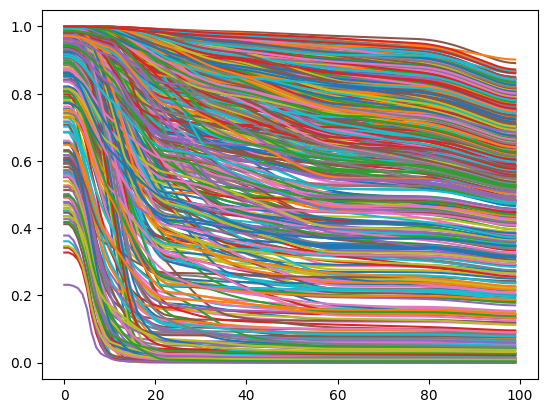

In [30]:
# plt.plot(interpolated_probs.T)
plt.plot(smoothed_interpolated_probs.T)
plt.show()